#REINFORCEMENT LEARNING

---

##0.REFERENCES AND CONTEXT

**Introduction**

Reinforcement Learning (RL) represents one of the most important paradigms in artificial intelligence. Unlike supervised learning, where models learn from labeled examples, reinforcement learning agents learn through interaction with an environment. The agent takes actions, observes consequences, receives rewards, and gradually discovers strategies that maximize long-term success.

This learning paradigm more closely resembles how humans and animals learn. A child learning to ride a bicycle is not provided with millions of labeled examples. Instead, the child interacts with the environment, falls, adjusts behavior, receives feedback, and gradually develops an effective strategy. Reinforcement learning formalizes this process mathematically.

In recent years, reinforcement learning has achieved remarkable success. DeepMind's AlphaGo defeated world champions in Go. Reinforcement learning agents mastered Atari video games, robotic control tasks, autonomous navigation systems, and complex resource allocation problems. Many modern AI systems combine reinforcement learning with deep neural networks, creating Deep Reinforcement Learning.

This notebook introduces one of the most influential algorithms in modern AI: the Deep Q-Network (DQN). DQN was developed by DeepMind and demonstrated that deep neural networks could successfully learn policies directly from environmental interactions. This breakthrough launched the modern era of reinforcement learning.

The environment used in this chapter is CartPole. The objective is simple but challenging. A pole is attached to a moving cart, and the agent must learn how to move the cart left or right in order to keep the pole balanced. Every time step the pole remains balanced, the agent receives a reward. The agent therefore learns through trial and error which actions maximize survival time.

Students will learn the fundamental concepts of reinforcement learning including states, actions, rewards, policies, Q-functions, experience replay, exploration versus exploitation, and target networks. These concepts form the foundation for many advanced systems including robotics, autonomous vehicles, game-playing agents, industrial optimization systems, and modern AI assistants.

The notebook demonstrates how neural networks can approximate Q-values, how replay buffers stabilize learning, and how reward signals drive behavior. Visualization tools help students observe the learning process and understand how policies improve over time.

By the end of this chapter, students will understand the fundamental mechanics of reinforcement learning and appreciate why Deep Q-Networks represent one of the most important milestones in artificial intelligence research.

##1.LIBRARIES AND ENVIRONMENT

In [1]:
# CELL 1
# Environment Setup

!pip -q install gymnasium

import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_DIR = Path("/content/chapter11_dqn")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Run ID: run_20260606_125248_utc
PyTorch: 2.11.0+cu128
CUDA Available: True
Device: cuda


##2.CREATING THE CART POLE ENVIRONMENT

**Explanation for Cell 2**

This cell creates the CartPole environment and examines its state and action spaces.

In [3]:
# CELL 2
# CartPole Environment

import gymnasium as gym

env = gym.make("CartPole-v1")

state, info = env.reset()

print("State Dimension:",
      env.observation_space.shape[0])

print("Action Space:",
      env.action_space.n)

print("Initial State:")
print(state)

State Dimension: 4
Action Space: 2
Initial State:
[ 0.04577427  0.04241027  0.03609908 -0.04004363]


##3.EXPLORING THE STATE SPACE

**Explanation for Cell 3**

This cell explores the state variables that describe the environment.

In [4]:
# CELL 3
# Explore State Space

state_labels = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Angular Velocity"
]

for label, value in zip(
    state_labels,
    state
):
    print(
        f"{label}: {value:.4f}"
    )

Cart Position: 0.0458
Cart Velocity: 0.0424
Pole Angle: 0.0361
Pole Angular Velocity: -0.0400


##4.DEFINITION OF THE DQN

**Explanation for Cell 4**

This cell defines the Deep Q-Network architecture used to estimate Q-values.

In [5]:
# CELL 4
# Deep Q Network

class DQN(nn.Module):

    def __init__(
        self,
        state_dim,
        action_dim
    ):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                state_dim,
                128
            ),
            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),
            nn.ReLU(),

            nn.Linear(
                128,
                action_dim
            )
        )

    def forward(
        self,
        x
    ):
        return self.network(x)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = DQN(
    state_dim,
    action_dim
).to(device)

target_net = DQN(
    state_dim,
    action_dim
).to(device)

target_net.load_state_dict(
    policy_net.state_dict()
)

print(policy_net)

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


##5.THE REPLAY BUFFER

**Explanation for Cell 5**

This cell implements the replay buffer used for experience replay.

In [6]:
# CELL 5
# Replay Buffer

from collections import deque

replay_buffer = deque(
    maxlen=10000
)

BATCH_SIZE = 64

print(
    "Replay Buffer Size:",
    replay_buffer.maxlen
)

Replay Buffer Size: 10000


##6.TRAINING THE DEEP Q NETWORK

**Explanation for Cell 6**

This cell trains the Deep Q-Network through interaction with the environment.

In [7]:
# CELL 6
# Training Loop

optimizer = optim.Adam(
    policy_net.parameters(),
    lr=0.001
)

gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

EPISODES = 300

reward_history = []

for episode in range(EPISODES):

    state, _ = env.reset()

    total_reward = 0

    done = False

    while not done:

        if random.random() < epsilon:

            action = env.action_space.sample()

        else:

            with torch.no_grad():

                state_tensor = torch.FloatTensor(
                    state
                ).unsqueeze(0).to(device)

                action = torch.argmax(
                    policy_net(state_tensor)
                ).item()

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        replay_buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

        state = next_state

        total_reward += reward

        if len(replay_buffer) >= BATCH_SIZE:

            batch = random.sample(
                replay_buffer,
                BATCH_SIZE
            )

            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(
                states
            ).to(device)

            actions = torch.LongTensor(
                actions
            ).unsqueeze(1).to(device)

            rewards = torch.FloatTensor(
                rewards
            ).to(device)

            next_states = torch.FloatTensor(
                next_states
            ).to(device)

            dones = torch.FloatTensor(
                dones
            ).to(device)

            q_values = policy_net(
                states
            ).gather(
                1,
                actions
            ).squeeze()

            with torch.no_grad():

                next_q = target_net(
                    next_states
                ).max(
                    dim=1
                )[0]

            target_q = rewards + gamma * next_q * (1 - dones)

            loss = nn.MSELoss()(
                q_values,
                target_q
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    reward_history.append(
        total_reward
    )

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    if episode % 10 == 0:

        target_net.load_state_dict(
            policy_net.state_dict()
        )

    if episode % 20 == 0:

        print(
            f"Episode {episode} "
            f"Reward {total_reward:.0f}"
        )

Episode 0 Reward 34


/tmp/ipykernel_419/109046888.py:72: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(


Episode 20 Reward 9
Episode 40 Reward 37
Episode 60 Reward 15
Episode 80 Reward 35
Episode 100 Reward 16
Episode 120 Reward 35
Episode 140 Reward 85
Episode 160 Reward 84
Episode 180 Reward 156
Episode 200 Reward 177
Episode 220 Reward 50
Episode 240 Reward 112
Episode 260 Reward 114
Episode 280 Reward 16


##7.VISUALIZATION OF THE TRAINING PROCESS

**Explanation for Cell 7**

This cell visualizes training rewards over time.

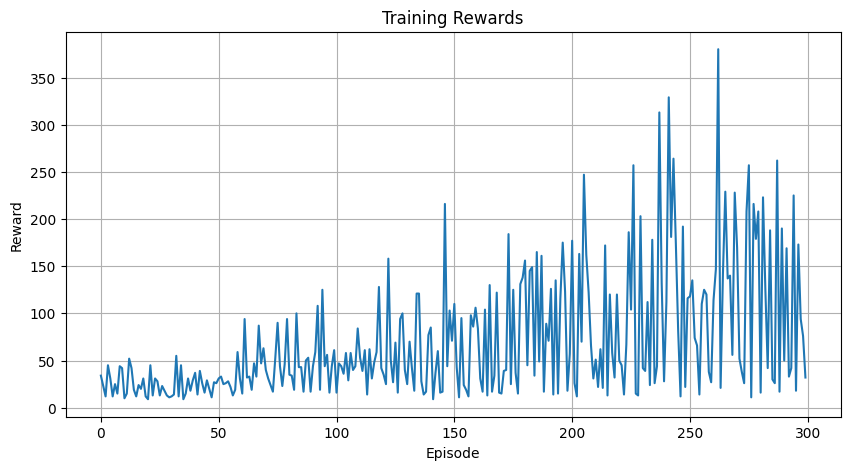

In [8]:
# CELL 7
# Reward Curve

plt.figure(
    figsize=(10,5)
)

plt.plot(
    reward_history
)

plt.title(
    "Training Rewards"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Reward"
)

plt.grid(True)

plt.show()
plt.close()

##8.EVALUATION

**Explanation for Cell 8**

This cell evaluates the trained agent without exploration.

In [9]:
# CELL 8
# Evaluation

evaluation_rewards = []

for _ in range(20):

    state, _ = env.reset()

    total_reward = 0

    done = False

    while not done:

        with torch.no_grad():

            state_tensor = torch.FloatTensor(
                state
            ).unsqueeze(0).to(device)

            action = torch.argmax(
                policy_net(
                    state_tensor
                )
            ).item()

        state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        total_reward += reward

    evaluation_rewards.append(
        total_reward
    )

average_reward = np.mean(
    evaluation_rewards
)

print(
    "Average Evaluation Reward:",
    average_reward
)

Average Evaluation Reward: 165.15


##9.EVALUATION OF THE POLICY

**Explanation for Cell 9**

This cell analyzes the learned policy.

In [10]:
# CELL 9
# Policy Analysis

test_state, _ = env.reset()

test_tensor = torch.FloatTensor(
    test_state
).unsqueeze(0).to(device)

with torch.no_grad():

    q_values = policy_net(
        test_tensor
    )

print("State:")
print(test_state)

print("\nQ Values:")
print(
    q_values.cpu().numpy()
)

State:
[-0.02482858 -0.04648538  0.03080654  0.00151744]

Q Values:
[[28.073639 28.27919 ]]


##10.PREFORMANCE METRICS

**Explanation for Cell 10**

This cell summarizes performance metrics and training statistics.

In [11]:
# CELL 10
# Performance Analysis

results = {

    "max_reward":
        float(max(reward_history)),

    "average_training_reward":
        float(np.mean(reward_history)),

    "average_evaluation_reward":
        float(average_reward),

    "episodes":
        EPISODES
}

print(
    json.dumps(
        results,
        indent=2
    )
)

with open(
    ARTIFACT_DIR /
    "results.json",
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=2
    )

{
  "max_reward": 380.0,
  "average_training_reward": 69.78333333333333,
  "average_evaluation_reward": 165.15,
  "episodes": 300
}


##11.EXPLANATION AND SUMMARIZATION

In [13]:
# CELL 11
# GPT-5.2 Analysis

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Analyze this DQN CartPole experiment.

Return strict JSON.

{json.dumps(results, indent=2)}
"""
)

print(
    response.output_text
)

{
  "summary": {
    "task": "CartPole (DQN)",
    "episodes": 300,
    "max_reward": 380.0,
    "average_training_reward": 69.78333333333333,
    "average_evaluation_reward": 165.15
  },
  "derived_metrics": {
    "generalization_gap_eval_minus_train": 95.36666666666667,
    "eval_to_train_ratio": 2.367081076452599,
    "max_to_eval_ratio": 2.300514978805207,
    "max_to_train_ratio": 5.44546875417714,
    "eval_as_fraction_of_max": 0.43460526315789475,
    "train_as_fraction_of_max": 0.1836403508771921
  },
  "performance_assessment": {
    "overall_level": "moderate",
    "stability_indicator": "uncertain (no variance/learning-curve provided)",
    "policy_quality": "improving but not near-solved",
    "notes": [
      "Evaluation reward substantially exceeds training reward, consistent with exploration during training (e.g., epsilon-greedy) depressing training returns.",
      "Best episode (380) shows the agent can perform well occasionally, but average evaluation (165.15) suggest

##12.CONCLUSIONS

**Conclusion**

This chapter introduced Reinforcement Learning through the Deep Q-Network algorithm. Unlike supervised learning, where models learn from labeled examples, reinforcement learning agents learn through interaction with an environment. This distinction fundamentally changes the nature of the learning process. Rather than being told the correct answer, the agent must discover successful strategies through experimentation and feedback.

The CartPole environment provided a simple yet powerful demonstration of this concept. The agent observed the environment, selected actions, received rewards, and gradually improved its policy. Through repeated interactions, the neural network learned to estimate Q-values, which represent expected future rewards associated with particular actions. These estimates allowed the agent to make increasingly effective decisions.

Several critical reinforcement learning concepts were introduced. States provided a representation of the environment. Actions allowed the agent to influence outcomes. Rewards supplied the learning signal. Policies defined decision-making behavior. Experience replay improved learning stability by reusing past experiences, while target networks reduced oscillations and divergence during optimization.

The Deep Q-Network illustrated how neural networks can approximate value functions. Instead of storing a table of Q-values, the network learned a general mapping from states to expected rewards. This capability allows reinforcement learning to scale to much larger and more complex environments than classical tabular approaches.

The reward curves demonstrated how learning progressed over time. Early episodes typically exhibited poor performance because the agent acted largely at random. As training continued, rewards increased as the policy improved. This gradual improvement reflects one of the most important characteristics of reinforcement learning: knowledge emerges through interaction rather than direct instruction.

Reinforcement learning has become a foundational technology in artificial intelligence. Applications include robotics, game playing, recommendation systems, industrial control, autonomous vehicles, portfolio optimization, and resource allocation. Many of the most impressive AI achievements of the last decade have relied heavily on reinforcement learning methods.

This chapter marks an important transition in the Machine Learning Laboratory series. Previous chapters focused primarily on representation learning and prediction. Reinforcement learning introduces decision-making under uncertainty. This shift lays the foundation for autonomous systems capable of planning, adapting, and optimizing behavior over time.

In the next chapter, we will move from reinforcement learning toward evolutionary computation and Genetic Algorithms. Whereas reinforcement learning improves policies through rewards and experience, evolutionary methods improve solutions through selection, mutation, and recombination. Together, these approaches form two of the most important paradigms for intelligent optimization and autonomous learning.